In [1]:
import pandas as pd

In [2]:
data=pd.read_json("/content/news_dataset.json")
data.head()


,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [3]:
data.shape

(12695, 2)

In [5]:
data.category.value_counts()

,count
category,
BUSINESS,4254
SPORTS,4167
CRIME,2893
SCIENCE,1381


In [6]:
min_samples=1381
data_business=data[data.category=="BUSINESS"].sample(min_samples,random_state=30)
data_SPORTS=data[data.category=="SPORTS"].sample(min_samples,random_state=30)
data_CRIME=data[data.category=="CRIME"].sample(min_samples,random_state=30)
data_SCIENCE=data[data.category=="SCIENCE"].sample(min_samples,random_state=30)

In [7]:
data_balanced=pd.concat([data_business,data_SPORTS,data_CRIME,data_SCIENCE],axis=0)
data_balanced.category.value_counts()

,count
category,
BUSINESS,1381
SPORTS,1381
CRIME,1381
SCIENCE,1381


In [8]:
target={"BUSINESS":0,"SPORTS":1,"CRIME":2,"SCIENCE":3}
data_balanced["category_number"]=data_balanced["category"].map({
   "BUSINESS":0,
   "SPORTS":1,
   "CRIME":2,
   "SCIENCE":3

})

In [9]:
data_balanced.head()

,text,category,category_number
9807,Female Authors Helped Bookstore Sales Rise For...,BUSINESS,0
10340,What's Happening at Zappos May Be All About th...,BUSINESS,0
7110,Why Wellness Programs At Work Are Failing,BUSINESS,0
7022,"Women in Business Q&A: Michele Marano, Real Es...",BUSINESS,0
8014,"Dodd-Frank: Five Years After On July 21, 2010,...",BUSINESS,0


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data_balanced.text,
    data_balanced.category_number,
    test_size=0.2,
    random_state=2022,
    stratify=data_balanced.category_number
)

In [14]:
print(X_train.shape)
X_train.head()

(4419,)


,text
10196,LOOK: Earth Isn't The Only Place With Torrenti...
7589,Ovulating Women Prefer Images of Penetration O...
6761,Nothing Says March Madness Like A Coach Stripp...
9769,13-Year Old Vanishes After Cliff Jumping In Ha...
3345,Bus Driver Who Killed 3 While Texting Was 'As ...


In [15]:
y_train.value_counts()

,count
category_number,
3,1105
2,1105
0,1105
1,1104


In [16]:
y_test.value_counts()

,count
category_number,
1,277
0,276
3,276
2,276


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
     ('vectorizer_bow', CountVectorizer(ngram_range = (1, 1))),
     ('Multi NB', MultinomialNB())
])


clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.88      0.82       276
           1       0.90      0.87      0.88       277
           2       0.87      0.89      0.88       276
           3       0.92      0.79      0.85       276

    accuracy                           0.86      1105
   macro avg       0.86      0.86      0.86      1105
weighted avg       0.86      0.86      0.86      1105



In [19]:
X_test[:5]

,text
9568,The Sharing Economy at a Crossroads Zipcar and...
1897,Critic Cooks Up 'Totally Different Theory' Abo...
2254,Brain Evolution Study Shows What We Gave Up To...
9602,Google Gains $65 Billion In Biggest One-Day Ra...
6393,"Officer Draws Gun On Man Filming Him, Asks If ..."


In [20]:
y_pred[:5]

array([0, 3, 3, 0, 2])

In [21]:
y_test[:5]

,category_number
9568,0
1897,3
2254,3
9602,0
6393,2


In [22]:

clf = Pipeline([
    ('vectorizer_1_2_gram', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter
     ('Multi NB', MultinomialNB())
])


clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.91      0.80       276
           1       0.93      0.82      0.87       277
           2       0.87      0.87      0.87       276
           3       0.91      0.77      0.84       276

    accuracy                           0.84      1105
   macro avg       0.86      0.84      0.85      1105
weighted avg       0.86      0.84      0.85      1105



In [23]:
clf = Pipeline([
    ('vectorizer_1_3_grams', CountVectorizer(ngram_range = (1, 3))),
     ('Multi NB', MultinomialNB())
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.91      0.80       276
           1       0.93      0.82      0.87       277
           2       0.87      0.87      0.87       276
           3       0.92      0.77      0.84       276

    accuracy                           0.84      1105
   macro avg       0.86      0.84      0.84      1105
weighted avg       0.86      0.84      0.84      1105



In [24]:
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)

In [26]:
data_balanced['preprocessed_txt'] = data_balanced['text'].apply(preprocess)

In [27]:
data_balanced.head()

,text,category,category_number,preprocessed_txt
9807,Female Authors Helped Bookstore Sales Rise For...,BUSINESS,0,Female Authors helped Bookstore sale rise Time...
10340,What's Happening at Zappos May Be All About th...,BUSINESS,0,happen Zappos School Bus Test past week write ...
7110,Why Wellness Programs At Work Are Failing,BUSINESS,0,Wellness Programs Work fail
7022,"Women in Business Q&A: Michele Marano, Real Es...",BUSINESS,0,woman Business Q&A Michele Marano Real Estate ...
8014,"Dodd-Frank: Five Years After On July 21, 2010,...",BUSINESS,0,Dodd Frank year July 21 2010 President Obama s...


In [30]:
x_train,x_test,y_train,y_test=train_test_split(
    data_balanced.preprocessed_txt,
    data_balanced.category_number,
    test_size=0.2,
    random_state=2022,
    stratify=data_balanced.category_number
)

In [31]:
clf=Pipeline([
    ('vectorizer_bow',CountVectorizer(ngram_range=(1,2)))
    ,("Multi NB",MultinomialNB())
])
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       276
           1       0.90      0.86      0.88       277
           2       0.84      0.92      0.88       276
           3       0.91      0.82      0.86       276

    accuracy                           0.86      1105
   macro avg       0.87      0.86      0.86      1105
weighted avg       0.87      0.86      0.86      1105



In [32]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[234,  11,  19,  12],
       [ 13, 238,  18,   8],
       [ 14,   4, 255,   3],
       [ 27,  10,  12, 227]])

Text(95.72222222222221, 0.5, 'Truth')

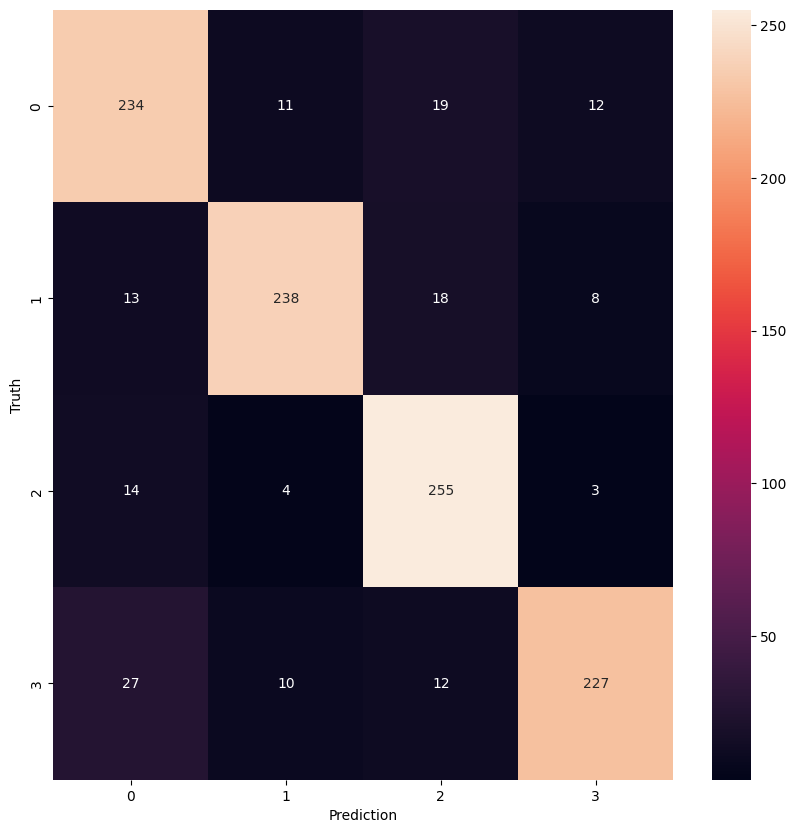

In [33]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,10))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')